# Which Parts of Attention Does an Image Actually Need?

An ablation study of the Vision Transformer on CIFAR-10.

Every figure and table below is rendered from the committed JSON files in `results/`.
Set `RUN_TRAINING = True` in the next cell to reproduce them from scratch.

In [1]:
%matplotlib inline

RUN_TRAINING = False

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

sys.path.append('..')

from src.evaluate import plot_confusion_matrix
from src.variants import DESCRIPTIONS, VARIANTS

RESULTS = Path('../results')


def load(name, seed=0):
    return json.loads((RESULTS / f'{name}_seed{seed}.json').read_text())


def seeds(name):
    return [load(name, s) for s in (0, 1, 2) if (RESULTS / f'{name}_seed{s}.json').exists()]

In [2]:
rows = []
for name in ['R1', 'R2', 'R3', 'V0'] + [n for n in VARIANTS if n.startswith('V') and n != 'V0']:
    runs = seeds(name)
    if not runs:
        continue
    acc = [r['test_accuracy'] for r in runs]
    rows.append((name, DESCRIPTIONS[name], np.mean(acc), np.std(acc),
                 runs[0].get('parameters', 0)))

print(f"{'ID':<5} {'variant':<45} {'accuracy':>16} {'params':>12}")
for name, desc, mean, std, params in rows:
    print(f'{name:<5} {desc:<45} {mean:>10.2f} ± {std:<4.2f} {params:>12,}')

ID    variant                                               accuracy       params
R1    MLP baseline (Lab 02)                              57.19 ± 0.07    3,676,682
R2    CNN with dropout (Lab 02)                          74.87 ± 0.87      553,514
R3    CLIP ViT-B/32 zero-shot (Lab 10)                   93.66 ± 0.00            0
V0    reference ViT: patch 4, depth 6, 4 heads, CLS      72.80 ± 0.27    1,794,058
V1    no positional encoding                             59.05 ± 0.40    1,794,058
V2    learned positional embeddings                      68.49 ± 0.84    1,806,538
V3    patch size 8                                       67.20 ± 0.40    1,821,706
V4    1 attention head                                   69.82 ± 0.27    1,794,058
V5    2 attention heads                                  71.57 ± 0.68    1,794,058
V6    8 attention heads                                  73.09 ± 0.15    1,794,058
V7a   depth 2                                            65.84 ± 0.40      605,962
V7b  

In [3]:
v0 = np.mean([r['test_accuracy'] for r in seeds('V0')])

print(f"{'ID':<5} {'ablation':<45} {'Δ vs V0':>10}")
for name in [n for n in VARIANTS if n.startswith('V') and n != 'V0']:
    runs = seeds(name)
    if not runs:
        continue
    delta = np.mean([r['test_accuracy'] for r in runs]) - v0
    print(f'{name:<5} {DESCRIPTIONS[name]:<45} {delta:>+10.2f}')

ID    ablation                                         Δ vs V0
V1    no positional encoding                            -13.75
V2    learned positional embeddings                      -4.31
V3    patch size 8                                       -5.59
V4    1 attention head                                   -2.98
V5    2 attention heads                                  -1.22
V6    8 attention heads                                  +0.29
V7a   depth 2                                            -6.95
V7b   depth 4                                            -1.71
V8    mean pooling instead of CLS                        +1.78
V9    augmentation disabled                              -5.24


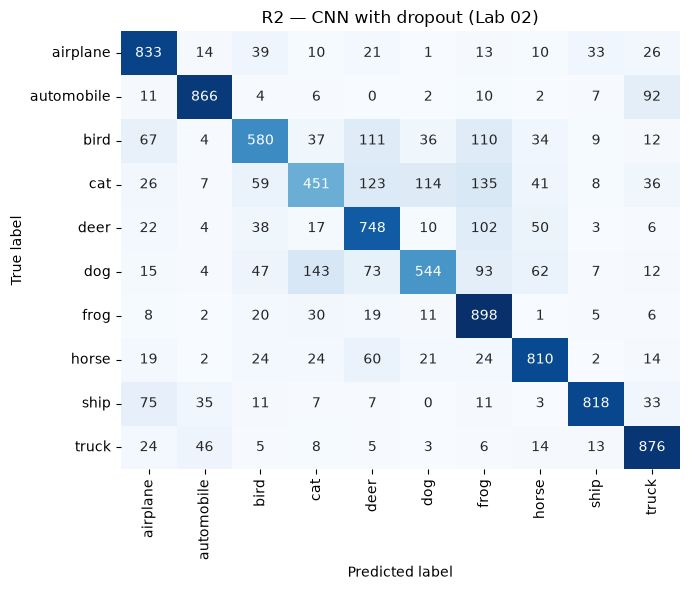

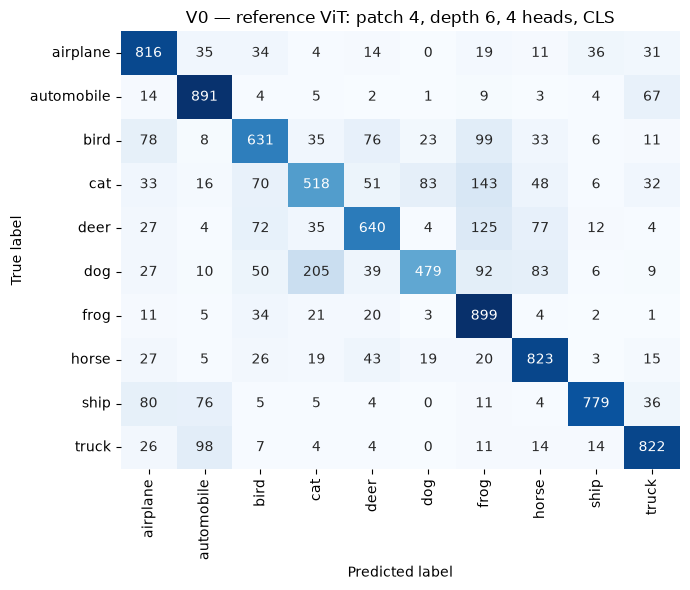

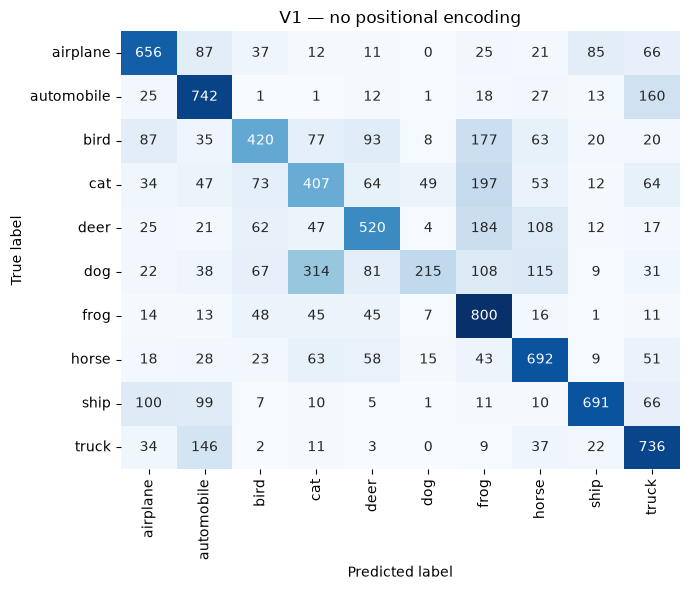

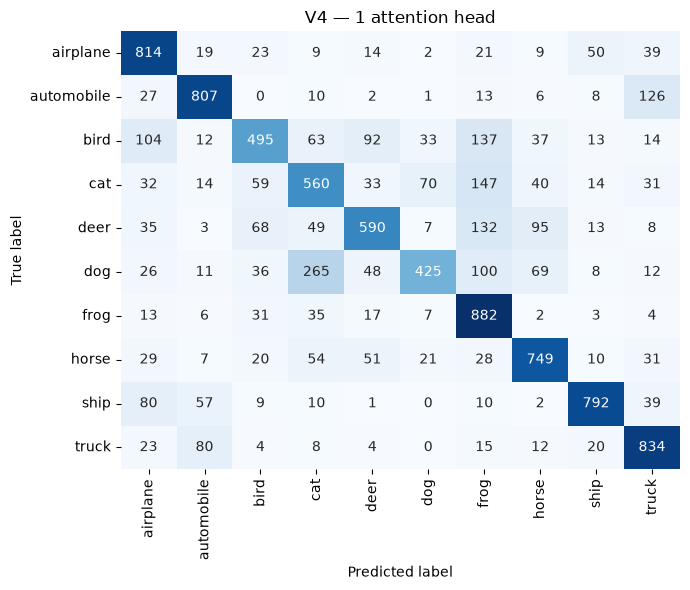

In [4]:
for name in ['R2', 'V0', 'V1', 'V4']:
    fig, ax = plt.subplots(figsize=(7, 6))
    plot_confusion_matrix(load(name)['confusion_matrix'],
                          f'{name} — {DESCRIPTIONS[name]}', ax=ax)
    plt.tight_layout()
    plt.show()

In [5]:
per_class = load('V0')['per_class']
print(f"{'class':<12} {'precision':>10} {'recall':>10} {'f1':>10}")
for name, m in per_class.items():
    print(f"{name:<12} {m['precision']:>10.3f} {m['recall']:>10.3f} {m['f1-score']:>10.3f}")

class         precision     recall         f1
airplane          0.716      0.816      0.763
automobile        0.776      0.891      0.830
bird              0.676      0.631      0.653
cat               0.609      0.518      0.560
deer              0.717      0.640      0.676
dog               0.783      0.479      0.594
frog              0.630      0.899      0.741
horse             0.748      0.823      0.784
ship              0.897      0.779      0.834
truck             0.800      0.822      0.811


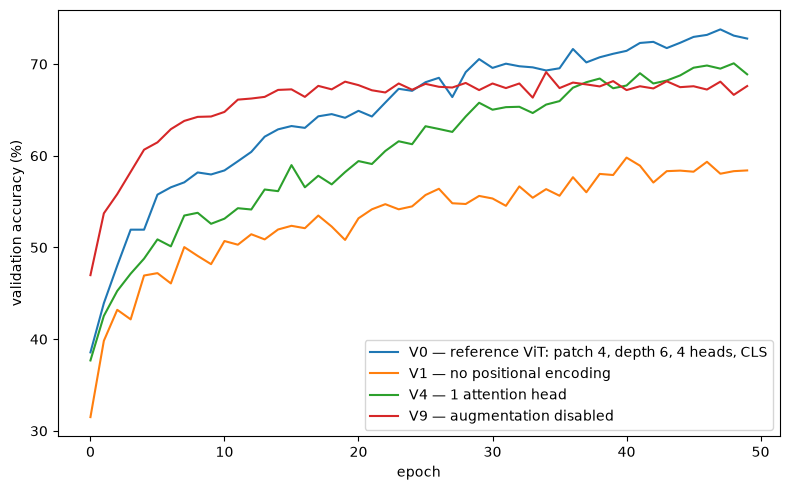

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
for name in ['V0', 'V1', 'V4', 'V9']:
    history = load(name)['history']
    ax.plot([h['epoch'] for h in history], [h['val_acc'] for h in history],
            label=f'{name} — {DESCRIPTIONS[name]}')
ax.set_xlabel('epoch')
ax.set_ylabel('validation accuracy (%)')
ax.legend()
plt.tight_layout()
plt.show()

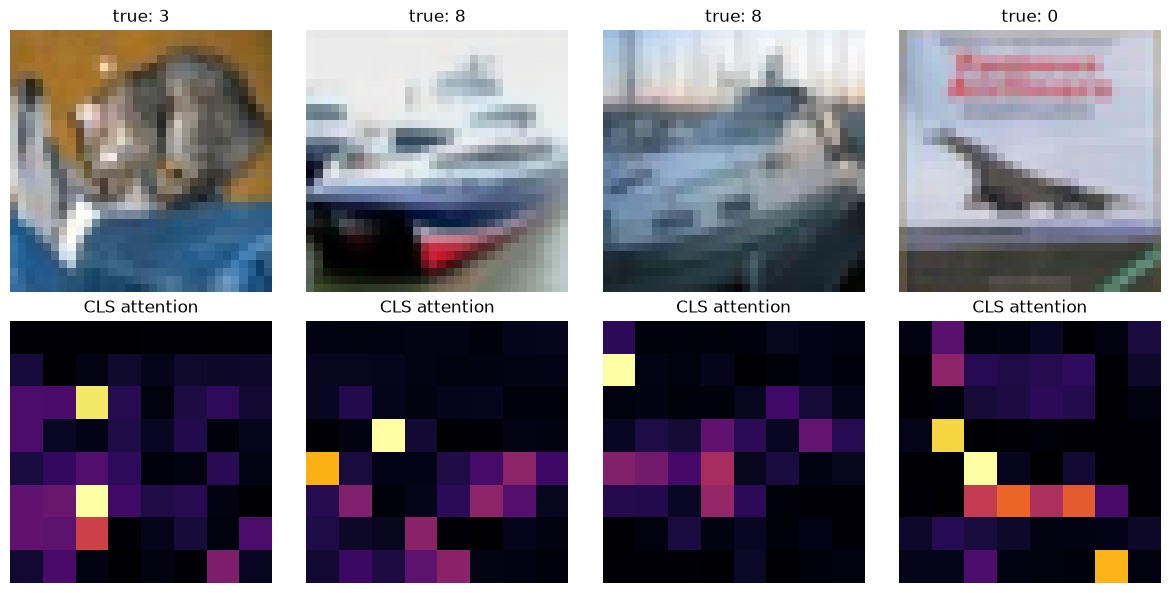

In [7]:
import torch

from src.attention import attention_maps, head_ablation_matrix
from src.data import get_device, get_loaders
from src.evaluate import denormalise
from src.train import build_model
from src.variants import config

checkpoint = RESULTS / 'V0_seed0.pt'
if checkpoint.exists():
    device = get_device()
    model = build_model(config('V0')).to(device)
    model.load_state_dict(torch.load(checkpoint, map_location=device))
    model.eval()

    _, _, test_loader = get_loaders(batch_size=8, augment=False)
    images, labels = next(iter(test_loader))
    maps = attention_maps(model, images.to(device))

    # CLS attention over the 64 patches, last layer, averaged over heads
    cls_attention = maps[-1][:, :, 0, 1:].mean(1).reshape(-1, 8, 8).cpu()

    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    for i in range(4):
        axes[0, i].imshow(denormalise(images[i]))
        axes[0, i].set_title(f'true: {labels[i].item()}')
        axes[0, i].axis('off')
        axes[1, i].imshow(cls_attention[i], cmap='inferno')
        axes[1, i].set_title('CLS attention')
        axes[1, i].axis('off')
    plt.tight_layout()
    plt.show()
else:
    print('Checkpoint not committed — rerun training locally to regenerate this figure.')

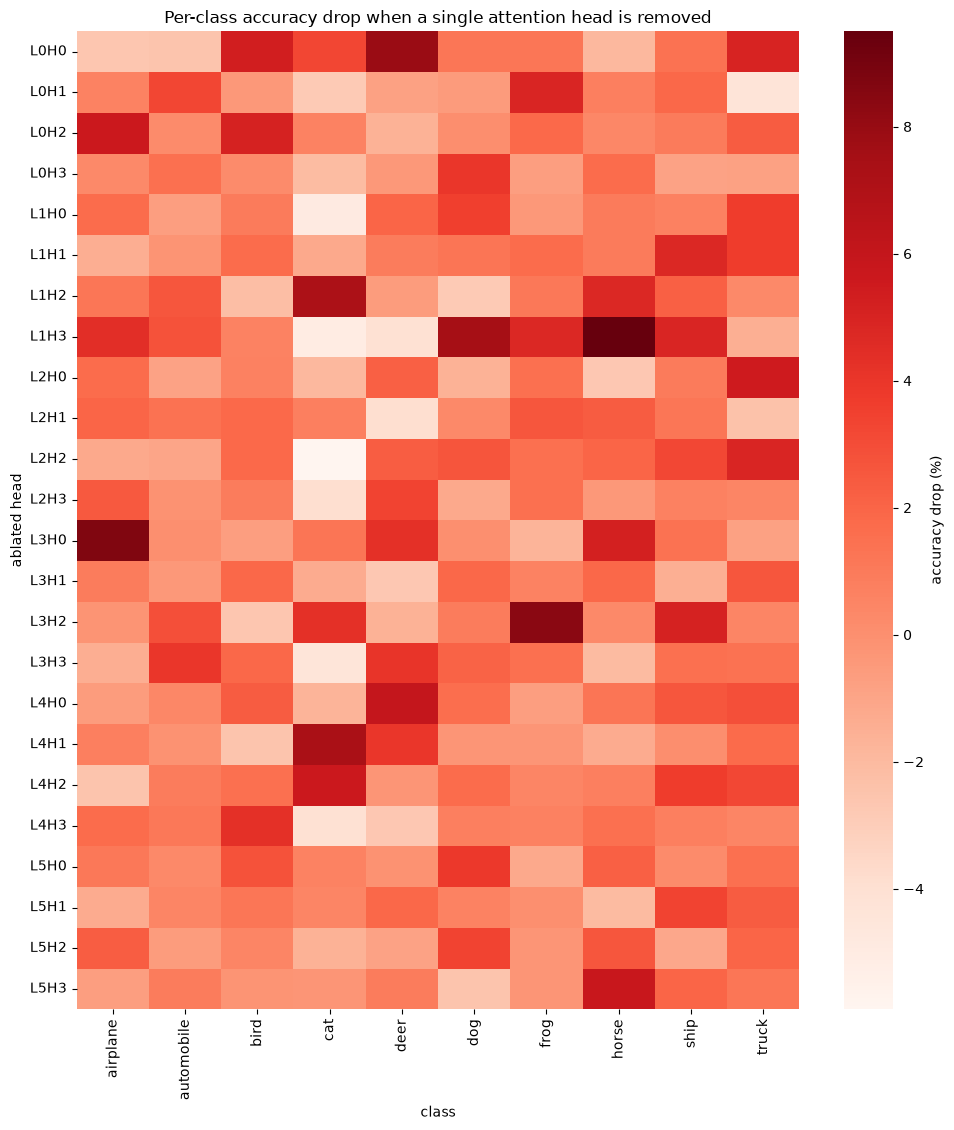

largest single-head effect: removing L1H3 costs 9.50 points on "horse"


In [8]:
import seaborn as sns

from src.data import CLASS_NAMES

if checkpoint.exists():
    _, _, ablation_loader = get_loaders(batch_size=256, augment=False)
    baseline, rows = head_ablation_matrix(model, ablation_loader, device)
    matrix = np.array([rows[k] for k in rows])

    fig, ax = plt.subplots(figsize=(10, 0.35 * len(rows) + 3))
    sns.heatmap(matrix, cmap='Reds', ax=ax, cbar_kws={'label': 'accuracy drop (%)'},
                xticklabels=CLASS_NAMES, yticklabels=list(rows))
    ax.set_xlabel('class')
    ax.set_ylabel('ablated head')
    ax.set_title('Per-class accuracy drop when a single attention head is removed')
    plt.tight_layout()
    plt.show()

    worst = max(((k, c, v) for k, row in rows.items()
                 for c, v in zip(CLASS_NAMES, row)), key=lambda r: r[2])
    print(f'largest single-head effect: removing {worst[0]} costs '
          f'{worst[2]:.2f} points on "{worst[1]}"')
else:
    print('Checkpoint not committed — rerun training locally to regenerate this figure.')